# Exploratory Data Analysis (EDA)
## Music Streaming Pipeline — Notebook 1 of 3

This notebook performs an initial exploratory analysis on the music streaming dataset, focusing on a core set of audio features and song popularity.

### What We Did
- **Loaded and merged** `songs.csv` and `song_audio_features.csv` on `song_id`
- **Filtered** the dataset down to four key features: `popularity`, `bpm`, `energy`, and `danceability`
- **Validated data quality** — confirmed zero duplicates and no null values, and removed rows with invalid BPM values (bpm = 0)
- **Computed summary statistics** using `.describe()` to understand the distribution of each feature
- **Plotted histograms** for all four features to visualise their distributions
- **Built a correlation heatmap** across the four features to identify any linear relationships

### Key Findings
- Song popularity is heavily right-skewed — the vast majority of songs have low popularity, with only a small number achieving high scores
- BPM and energy show a moderate positive correlation with danceability, which is expected since danceability is a composite metric derived from tempo and energy
- No strong linear correlations were found between the raw audio features and song popularity in this subset

### Next Step
Notebook 02 expands the feature set by joining artist and album data, and runs a full Pearson correlation analysis across all numeric features to identify which variables are most predictive of song popularity.

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## IMPORT TABLES

In [79]:
songs = pd.read_csv('../exports/songs.csv')
audio_features = pd.read_csv('../exports/song_audio_features.csv')

In [80]:
audio_features.head()

,song_id,bpm,energy,spectral_centroid,zero_crossing_rate,danceability,preview_url,harmonic_ratio,percussive_ratio,analysis_date
0,0008IPeppDTYa718PUDx2u,143.555,0.14089,2840.898,0.10469,0.30672,https://p.scdn.co/mp3-preview/c033e97cf9fcb34f...,0.57813,0.42187,2026-01-07 15:07:39.496286
1,000LW3O97XPr9lQ9rmQ6PX,0.000,0.15378,145.715,0.00830,0.07855,https://p.scdn.co/mp3-preview/249034d2006abd70...,0.91263,0.08737,2026-01-01 20:22:45.325163
2,000TJlEJQ3nafsm1hBWpoj,135.999,0.16379,2312.848,0.10800,0.30749,https://p.scdn.co/mp3-preview/926826525a487214...,0.62414,0.37586,2026-01-07 15:07:39.495713
3,000zYgBirXxgFkpAXOt0EB,112.347,0.15744,2676.543,0.12071,0.27138,https://p.scdn.co/mp3-preview/9ec10940ab28c537...,0.44074,0.55926,2026-01-01 20:22:45.325479
4,0014ghR6rYIIpdPSgF8JLT,135.999,0.09288,2635.791,0.06523,0.26348,https://p.scdn.co/mp3-preview/3d6ba1a8469a9c43...,0.81333,0.18667,2026-04-28 11:19:51.089473


## MERGING TABLES

In [81]:
df = audio_features.merge(songs, on='song_id', how='inner')

In [82]:
df.head()

,song_id,bpm,energy,spectral_centroid,zero_crossing_rate,danceability,preview_url,harmonic_ratio,percussive_ratio,analysis_date,...,duration_minutes,engagement_ratio,release_date,release_date_precision,is_explicit,popularity,track_number,is_playable,created_at,updated_at
0,0008IPeppDTYa718PUDx2u,143.555,0.14089,2840.898,0.10469,0.30672,https://p.scdn.co/mp3-preview/c033e97cf9fcb34f...,0.57813,0.42187,2026-01-07 15:07:39.496286,...,4.38,0.00056,2026-01-02,day,f,25,18,t,2026-01-07 14:39:20.177381,2026-01-12 21:12:22.595716
1,000LW3O97XPr9lQ9rmQ6PX,0.000,0.15378,145.715,0.00830,0.07855,https://p.scdn.co/mp3-preview/249034d2006abd70...,0.91263,0.08737,2026-01-01 20:22:45.325163,...,2.75,0.01556,2025-10-17,day,f,46,1,t,2025-12-30 13:16:00.711315,2026-01-02 20:36:45.676219
2,000TJlEJQ3nafsm1hBWpoj,135.999,0.16379,2312.848,0.10800,0.30749,https://p.scdn.co/mp3-preview/926826525a487214...,0.62414,0.37586,2026-01-07 15:07:39.495713,...,2.17,0.17877,2023-03-31,day,t,53,3,t,2026-01-06 23:51:07.544505,2026-01-07 11:44:23.117807
3,000zYgBirXxgFkpAXOt0EB,112.347,0.15744,2676.543,0.12071,0.27138,https://p.scdn.co/mp3-preview/9ec10940ab28c537...,0.44074,0.55926,2026-01-01 20:22:45.325479,...,2.10,0.07860,2025-07-04,day,t,64,1,t,2025-12-30 13:33:34.846891,2026-01-07 13:11:27.270501
4,0014ghR6rYIIpdPSgF8JLT,135.999,0.09288,2635.791,0.06523,0.26348,https://p.scdn.co/mp3-preview/3d6ba1a8469a9c43...,0.81333,0.18667,2026-04-28 11:19:51.089473,...,3.05,NaN,2024-10-30,day,t,16,1,t,2026-01-07 18:15:52.464814,2026-01-07 18:15:55.473477


## FILTERING TABLE

In [83]:
df= df[['song_id', 'popularity', 'danceability', 'bpm', 'energy']]

## SUMMARY STATS

In [84]:
df.columns

Index(['song_id', 'popularity', 'danceability', 'bpm', 'energy'], dtype='object')

In [85]:
df.duplicated().sum()

np.int64(0)

There are no duplicate rows meaning that we don't need to filter the table.

In [86]:
df.describe()

,popularity,danceability,bpm,energy
count,100441.000000,100441.000000,100441.000000,100441.000000
mean,29.253572,0.301221,119.772436,0.205596
std,19.536278,0.065768,29.429944,0.090233
min,1.000000,0.000100,0.000000,0.000000
25%,13.000000,0.257350,99.384000,0.140360
50%,27.000000,0.300130,117.454000,0.191830
75%,44.000000,0.344340,135.999000,0.271130
max,99.000000,0.625260,287.109000,0.805060


* Popularity: The mean popularity for 100k+ songs is 29.2. This indicates that the distribution is likely skewed to the right since the range of values is 0-99. The quartiles of data indicate that the majority of the data (75%+) lies under a popularity score of 50. This mimics real world songs as the majority of songs published are not viral hits. Most are undiscovered songs that don't chart or generate tons of streams. It appears that this feature might have some outliers on the higher end of the popularity spectrum because the 75% quartile is 44 and the max is 99 which is around 3 standard deviations between these bounds. 

* Danceability: The mean danceability score is .3 which is relatively low compared to what I initially thought. It could be by chance that the songs samples tend to have a lower danceability metric. Its important to note that danceability is a calculated value from energy, normalized bpm, and zero_crossing_rate. Therefore, it will likely mimic the trends observed in these features. Most of the songs are concentrated in the .2-.35 range meaning that there isn't a ton of variation which is corroborated by the concentration in energy and bpm. However, there does seem to be some outliers on either side of the spectrum with the min value being ~0 and the max being .62.

* BPM: The average BPM is ~120 which is relatively fast for a song especially due to the trends we observe in danceability and energy. THere are some outliers with songs that have 0 BPM and others that have a BPM of almost 300. Most of the data is concentrated within a 40 BPM range (99-135) which is consistent with the other features in this dataset.

* Energy: The average energy is relatively low with a value of ~.20. With most songs having a BPM of 100+ I would assume that the energy levels would be higher. However, I don't know how this value is calculated. I also assume that the preview url is generated from the beginning of the song which in some cases doesn't showcase the full range of a song's energy. At times, songs build throughout the song and therefore my data doesn't reflect that.



In [118]:
df=df[df['bpm']>0]

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99906 entries, 0 to 100440
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   song_id       99906 non-null  object 
 1   popularity    99906 non-null  int64  
 2   danceability  99906 non-null  float64
 3   bpm           99906 non-null  float64
 4   energy        99906 non-null  float64
dtypes: float64(3), int64(1), object(1)
memory usage: 4.6+ MB


There is no null data and the datatypes make sense with what the features represent. No transformations are required at this time.

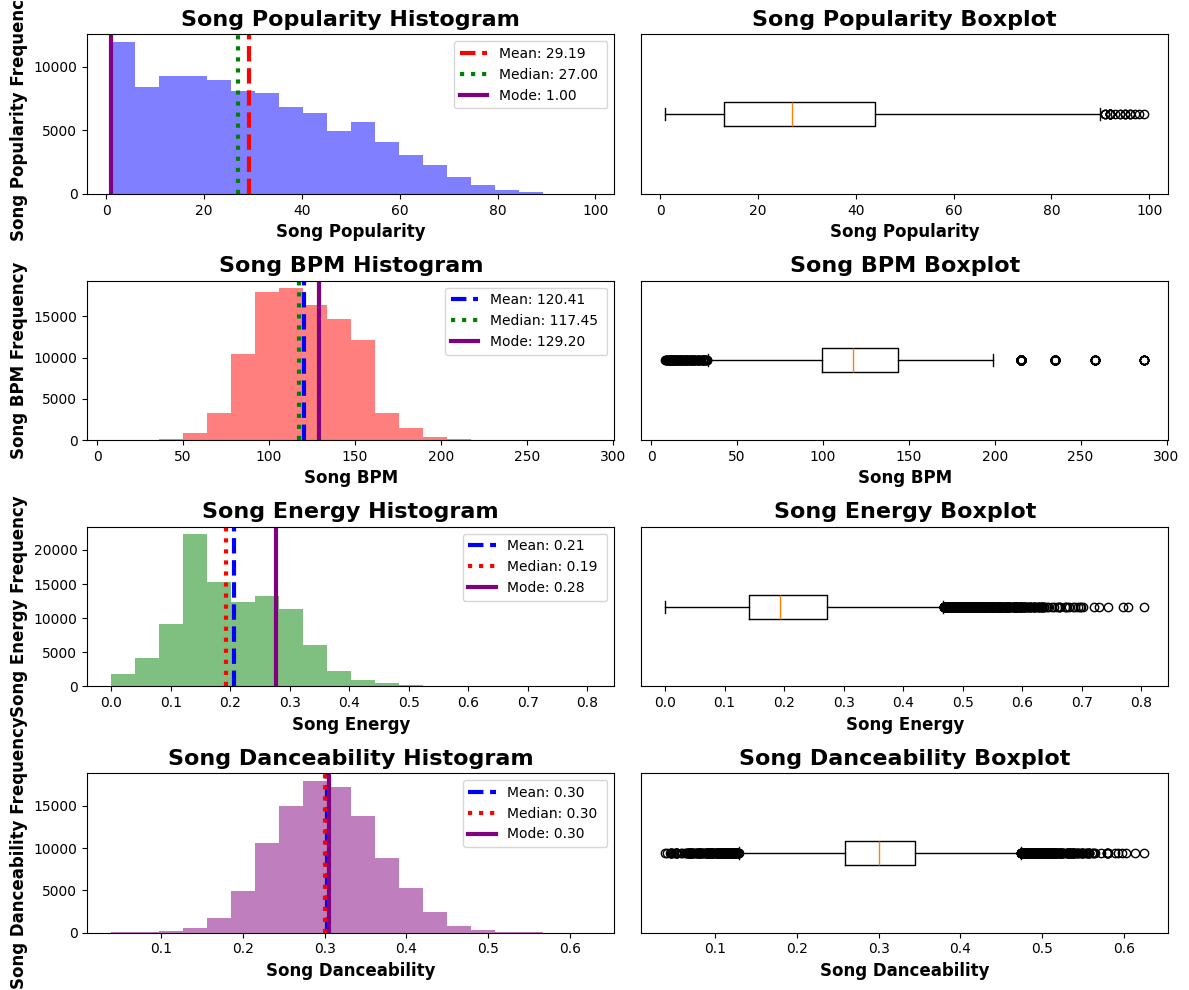

In [120]:
fig, axes = plt.subplots(4,2, figsize = (12,10))

axes[0,0].hist(df['popularity'], bins=20, color='blue', alpha=.5)
axes[0,0].set_xlabel('Song Popularity', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Song Popularity Frequency', fontsize=12, fontweight='bold')
axes[0,0].set_title('Song Popularity Histogram', fontweight='bold', fontsize=16)
axes[0,0].axvline(df['popularity'].mean(), label=f'Mean: {df['popularity'].mean():.2f} ', color='red', linewidth=3, linestyle='--')
axes[0,0].axvline(df['popularity'].median(), label=f'Median: {df['popularity'].median():.2f} ', color='green', linewidth=3, linestyle=':')
axes[0,0].axvline(df['popularity'].mode()[0], label=f'Mode: {df['popularity'].mode()[0]:.2f} ', color='purple', linewidth=3)
axes[0,0].legend()

axes[0,1].boxplot(df['popularity'], vert=False)
axes[0,1].set_xlabel('Song Popularity', fontsize=12, fontweight='bold')
axes[0,1].set_yticks([])
axes[0,1].set_title('Song Popularity Boxplot', fontweight='bold', fontsize=16)

axes[1,0].hist(df['bpm'], bins=20, color='red', alpha=.5)
axes[1,0].set_xlabel('Song BPM', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Song BPM Frequency', fontsize=12, fontweight='bold')
axes[1,0].set_title('Song BPM Histogram', fontweight='bold', fontsize=16)
axes[1,0].axvline(df['bpm'].mean(), label=f'Mean: {df['bpm'].mean():.2f} ', color='blue', linewidth=3, linestyle='--')
axes[1,0].axvline(df['bpm'].median(), label=f'Median: {df['bpm'].median():.2f} ', color='green', linewidth=3, linestyle=':')
axes[1,0].axvline(df['bpm'].mode()[0], label=f'Mode: {df['bpm'].mode()[0]:.2f} ', color='purple', linewidth=3)
axes[1,0].legend()

axes[1,1].boxplot(df['bpm'], vert=False)
axes[1,1].set_xlabel('Song BPM', fontsize=12, fontweight='bold')
axes[1,1].set_yticks([])
axes[1,1].set_title('Song BPM Boxplot', fontsize=16, fontweight='bold')


axes[2,0].hist(df['energy'], bins=20, color='green', alpha=.5)
axes[2,0].set_xlabel('Song Energy', fontsize=12, fontweight='bold')
axes[2,0].set_ylabel('Song Energy Frequency', fontsize=12, fontweight='bold')
axes[2,0].set_title('Song Energy Histogram', fontsize=16, fontweight='bold')
axes[2,0].axvline(df['energy'].mean(), label=f'Mean: {df['energy'].mean():.2f} ', color='blue', linewidth=3, linestyle='--')
axes[2,0].axvline(df['energy'].median(), label=f'Median: {df['energy'].median():.2f} ', color='red', linewidth=3, linestyle=':')
axes[2,0].axvline(df['energy'].mode()[0], label=f'Mode: {df['energy'].mode()[0]:.2f} ', color='purple', linewidth=3)
axes[2,0].legend()

axes[2,1].boxplot(df['energy'], vert=False)
axes[2,1].set_xlabel('Song Energy', fontsize=12, fontweight='bold')
axes[2,1].set_yticks([])
axes[2,1].set_title('Song Energy Boxplot', fontsize=16, fontweight='bold')


axes[3,0].hist(df['danceability'], bins=20, color='purple', alpha=.5)
axes[3,0].set_xlabel('Song Danceability', fontsize=12, fontweight='bold')
axes[3,0].set_ylabel('Song Danceability Frequency', fontsize=12, fontweight='bold')
axes[3,0].set_title('Song Danceability Histogram', fontsize=16, fontweight='bold')
axes[3,0].axvline(df['danceability'].mean(), label=f'Mean: {df['danceability'].mean():.2f} ', color='blue', linewidth=3, linestyle='--')
axes[3,0].axvline(df['danceability'].median(), label=f'Median: {df['danceability'].median():.2f} ', color='red', linewidth=3, linestyle=':')
axes[3,0].axvline(df['danceability'].mode()[0], label=f'Mode: {df['danceability'].mode()[0]:.2f} ', color='purple', linewidth=3)
axes[3,0].legend()

axes[3,1].boxplot(df['danceability'], vert=False)
axes[3,1].set_xlabel('Song Danceability', fontsize=12, fontweight='bold')
axes[3,1].set_yticks([])
axes[3,1].set_title('Song Danceability Boxplot', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()



* Popularity: This feature is skewed to the right with the majority of the songs having a popularity score under 20. Again this mirrors the reality of song popularity distributions as most songs released will not be viral hits, only a few achieve this status. The mode of this distrbution is extremely low (1), the mean is much higher (29), and the median is 27. The boxplot shows that most of the data is concentrated below 44 and there are a few outliers in the higher popularity ranges.

* BPM: The distribution is VERY roughly normal. I wouldn't say that the distribution is skewed one way or another but it is not bell shaped. The mean (120), median (117), and mode (129) are closer together than they are in the popularity distribution. One assumption of a normal distribution is mode=median=mean. While this is not true, it is closer than some of the other distributions we are investigating. There are quite a few outliers in this distribution on either side of the spectrum. Values below ~48 and above ~180 are outliers.

* Energy: This distribution shows a slight right skew with a majority of the songs concentrated below .25. The outliers in this distribution are above .47 energy levels. There are quite a few of outliers in this distribution.

*Danceability: This distribution is approximately normal. The mean, median, and mode are all the same which is one of the assumptions of a normal distribution. Additionally, the histogram is beautifully bell-shaped. The outliers seem to be evenly distributed.

<Axes: >

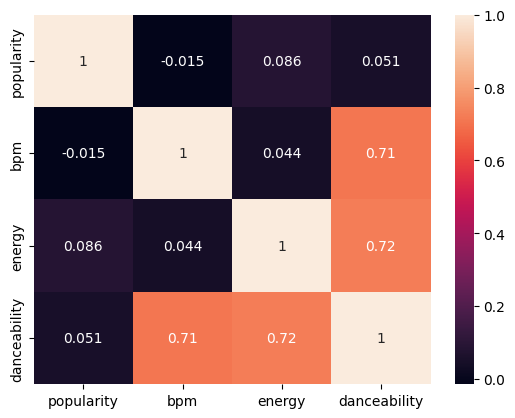

In [117]:
sns.heatmap(df[['popularity', 'bpm', 'energy', 'danceability']].corr(), annot=True )

Most variables in this dataset show negligible correlation with one another. The notable exception is the strong positive correlation between danceability and both BPM and energy. This is expected and not a meaningful discovery - danceability is a composite metric calculated directly from normalized BPM (30% weight), energy (50% weight), and zero crossing rate (20% weight). Including these features together in a predictive model would introduce multicollinearity.

Popularity shows near-zero correlation with all audio features, reinforcing the finding from the ML modeling notebook that signal-based features alone are insufficient predictors of commercial success. External factors such as playlist placement and marketing spend likely drive the variation that these features cannot explain.